In [1]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from IPython.display import Image, display
import io

import xarray as xr

from trotter_MPO import *
from qiskit_trotter_circuit import *
from qiskit_to_quimb import *

from one_hot_MPO_projector import mpo_prod_one_hot_projector

from qiskit import transpile

# MPO tests

## Compute and save

### Binary

In [76]:
D = 1
W = 0
dt = 0.2

for p in [1E-4, 1E-3, 1E-2]:
    for nb in [6]:
        for n_steps in [5]:
            fidelity_lists = []
            qc = binary_gray_trotter_circuit(D, nb, 0, dt, n_steps)
            qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

            ideal_mps = noisy_qc_mps_sim(qc, 0)
            noisy_mpo = noisy_qc_mpo_sim(qc, p)

            qu.save_to_disk(ideal_mps, f"ideal_mps/nb={nb}_dt={dt}_nsteps={n_steps}_p={p}.mps")
            qu.save_to_disk(noisy_mpo, f"noisy_mpo/nb={nb}_dt={dt}_nsteps={n_steps}_p={p}.mpo")

            #F = np.abs(perfect_mps.H @ (noisy_mpo.apply(perfect_mps, compress=True, max_bond=None, cutoff=1E-15)))
            #fidelity_lists.append(F)

100%|██████████| 1091/1091 [00:48<00:00, 22.33it/s]


### One-hot

In [ ]:
D = 1
dt = 0.2

for p in [1E-2]:
    for n, q in [(2, 8), (3, 4)]:
        for n_steps in [5]:
            fidelity_lists = []
            qc = one_hot_gray_trotter_circuit(D, n, q, 0, dt, n_steps)
            qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

            ideal_mps = noisy_qc_mps_sim(qc, 0)
            noisy_mpo = noisy_qc_mpo_sim(qc, p)

            qu.save_to_disk(ideal_mps, f"ideal_mps/n={n}_q={q}_dt={dt}_nsteps={n_steps}_p={p}.mps")
            qu.save_to_disk(noisy_mpo, f"noisy_mpo/nb={nb}_dt={dt}_nsteps={n_steps}_p={p}.mpo")

            #F = np.abs(perfect_mps.H @ (noisy_mpo.apply(perfect_mps, compress=True, max_bond=None, cutoff=1E-15)))
            #fidelity_lists.append(F)

 90%|████████▉ | 816/908 [19:51:21<10:35:52, 414.70s/it]

In [ ]:
dt = 0.05
for p in [1E-4, 1E-3, 1E-2]:
    for nb in [6]:
        for n_steps in [5]:
            fidelity_lists = []
            qc = binary_gray_trotter_circuit(1, nb, 0, dt, n_steps)
            qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

            ideal_mps = noisy_qc_mps_sim(qc, 0)
            noisy_mpo = noisy_qc_mpo_sim(qc, p)

            qu.save_to_disk(ideal_mps, f"ideal_mps/nb={nb}_dt={dt}_nsteps={n_steps}_p={p}.mps")
            qu.save_to_disk(noisy_mpo, f"noisy_mpo/nb={nb}_dt={dt}_nsteps={n_steps}_p={p}.mpo")

            #F = np.abs(perfect_mps.H @ (noisy_mpo.apply(perfect_mps, compress=True, max_bond=None, cutoff=1E-15)))
            #fidelity_lists.append(F)

In [ ]:
dt = 0.05
for p in [1E-4, 1E-3, 1E-2]:
    for n, q in [(2, 8), (3, 4)]:
        for n_steps in [5]:
            fidelity_lists = []
            qc = one_hot_gray_trotter_circuit(1, n, q, 0, dt, n_steps)
            qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

            ideal_mps = noisy_qc_mps_sim(qc, 0)
            noisy_mpo = noisy_qc_mpo_sim(qc, p)

            qu.save_to_disk(ideal_mps, f"ideal_mps/n={n}_q={q}_dt={dt}_nsteps={n_steps}_p={p}.mps")
            qu.save_to_disk(noisy_mpo, f"noisy_mpo/nb={nb}_dt={dt}_nsteps={n_steps}_p={p}.mpo")

            #F = np.abs(perfect_mps.H @ (noisy_mpo.apply(perfect_mps, compress=True, max_bond=None, cutoff=1E-15)))
            #fidelity_lists.append(F)

## Load and plot

In [ ]:
D = 1
W = 0
dt = 0.05
p = 1E-3


one_hot_F = xr.DataArray(
    np.full((4, 9, 10), np.nan),
    dims=("n", "q", "n_steps", "p"),
    name="fidelity",
)

one_hot_prob = xr.DataArray(
    np.full((4, 9, 10), np.nan),
    dims=("n", "q", "n_steps"),
    name="sucess probability",
)

for n, q in [(2, 8), (3, 4)]:
    proj_mpo = mpo_prod_one_hot_projector(n, q)
    for n_steps in range(10):
        fidelity_lists = []
        qc = one_hot_gray_trotter_circuit(D, n, q, W, dt, n_steps)
        qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

        ideal_mps = qu.load_from_disk(f"ideal_mps/n={n}_q={q}_dt={dt}_nsteps={n_steps}_p={p}.mps")
        noisy_mpo = qu.load_from_disk(f"noisy_mpo/n={n}_q={q}_dt={dt}_nsteps={n_steps}_p={p}.mpo")

        F = np.abs(ideal_mps.H @ noisy_mpo.apply(ideal_mps))
        prob = np.abs((proj_mpo.apply(noisy_mpo)).trace())
        
        one_hot_F.values[n, q, n_steps] = F
        one_hot_prob.values[n, q, n_steps] = prob

binary_F = xr.DataArray(
    np.full((10, 10), np.nan),
    dims=("nb", "n_steps"),
    name="fidelity",
)

for nb in [6]:
    for n_steps in range(10):
        fidelity_lists = []
        qc = binary_gray_trotter_circuit(D, nb, W, dt, n_steps)
        qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

        ideal_mps = qu.load_from_disk(f"ideal_mps/nb={nb}_dt={dt}_nsteps={n_steps}_p={p}.mps")
        noisy_mpo = qu.load_from_disk(f"noisy_mpo/nb={nb}_dt={dt}_nsteps={n_steps}_p={p}.mpo")

        F = np.abs(ideal_mps.H @ noisy_mpo.apply(ideal_mps, compress=True, max_bond=None, cutoff=1E-15))
        binary_F.values[nb, n_steps] = F

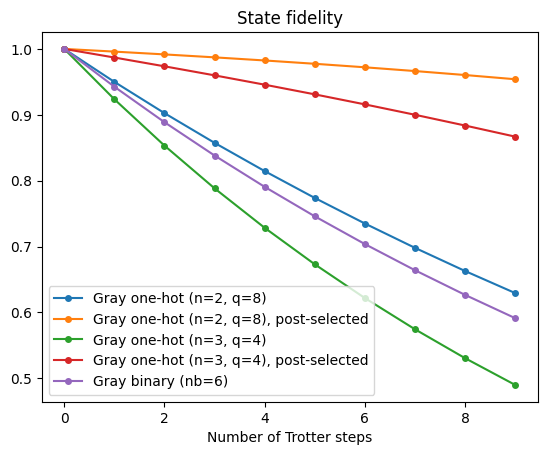

In [75]:
for (n, q) in [(2, 8), (3, 4)]:
    plt.plot(one_hot_F.sel(n=n, q=q), label=f"Gray one-hot (n={n}, q={q})", marker="o", markersize=4)
    plt.plot(one_hot_F.sel(n=n, q=q)/one_hot_prob.sel(n=n, q=q), label=f"Gray one-hot (n={n}, q={q}), post-selected", marker="o", markersize=4)
plt.plot(binary_F.sel(nb=6), label="Gray binary (nb=6)", marker="o", markersize=4)
plt.xlabel("Number of Trotter steps")
plt.title(f"State fidelity")
plt.legend()
plt.show()

In [ ]:
D = 1
n = 2
q = 8
W = 0
dt = 0.1
p = 1E-4

use_mps = False
shots = 100

for n_steps in [10]:
    fidelity_lists = []
    qc = one_hot_gray_trotter_circuit(D, n, q, W, dt, n_steps)
    qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)
    if use_mps:
        perfect_mps = noisy_qc_mps_sim(qc, 0)
        for _ in range(shots):
            noisy_mps = noisy_qc_mps_sim(qc, p)
            F = np.abs(noisy_mps.H @ perfect_mps)
            fidelity_lists.append(F)
    else:
        perfect_mps = noisy_qc_mps_sim(qc, 0)
        noisy_mpo = noisy_qc_mpo_sim(qc, p)
        F = np.abs(perfect_mps.H @ (noisy_mpo.apply(perfect_mps, compress=True, max_bond=None, cutoff=1E-15)))
        fidelity_lists.append(F)

 18%|█▊        | 327/1783 [01:07<04:59,  4.85it/s]


KeyboardInterrupt: 

# MPS tests

In [ ]:
D = 1
n = 2
q = 8
W = 0
dt = 0.1
p = 1E-4

use_mps = False
shots = 100

for n_steps in [10]:
    fidelity_lists = []
    qc = one_hot_gray_trotter_circuit(D, n, q, W, dt, n_steps)
    qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)
    if use_mps:
        perfect_mps = noisy_qc_mps_sim(qc, 0)
        for _ in range(shots):
            noisy_mps = noisy_qc_mps_sim(qc, p)
            F = np.abs(noisy_mps.H @ perfect_mps)
            fidelity_lists.append(F)
    else:
        perfect_mps = noisy_qc_mps_sim(qc, 0)
        noisy_mpo = noisy_qc_mpo_sim(qc, p)
        F = np.abs(perfect_mps.H @ (noisy_mpo.apply(perfect_mps, compress=True, max_bond=None, cutoff=1E-15)))
        fidelity_lists.append(F)

 18%|█▊        | 327/1783 [01:07<04:59,  4.85it/s]


KeyboardInterrupt: 

In [33]:
np.mean(fidelity_lists)

np.float64(0.9401773980883251)

In [4]:
import random

PAULIS_2Q = [
    (p1, p2)
    for p1 in ['I','X','Y','Z']
    for p2 in ['I','X','Y','Z']
    if not (p1 == 'I' and p2 == 'I')
]

def random_two_qubit_pauli(rng):
    return rng.choice(PAULIS_2Q)

rng = random.Random(None)


In [50]:
np.abs(qc_mps.H @ direct_mps)

np.float64(0.9999999999999998)

In [80]:
binary_gray_trotter_circuit(1, 2, 0, 0.1, 1).draw()

┌───┐┌──────────┐                      ┌─┐   
q_0: ┤ X ├┤ Rx(-0.2) ├──────────■───────────┤M├───
     ├───┤└──────────┘┌─────────┴──────────┐└╥┘┌─┐
q_1: ┤ X ├────────────┤ U(-0.2,-π/2,π/2,0) ├─╫─┤M├
     └───┘            └────────────────────┘ ║ └╥┘
c: 2/════════════════════════════════════════╩══╩═
                                             0  1

C:\Users\Jielun\AppData\Local\Temp\ipykernel_257580\3936850102.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  ymin, ymax = float(np.min(y_all)), float(np.max(y_all))
c:\Users\Jielun\Documents\GitHub\one_hot_QTT\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Jielun\Documents\GitHub\one_hot_QTT\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


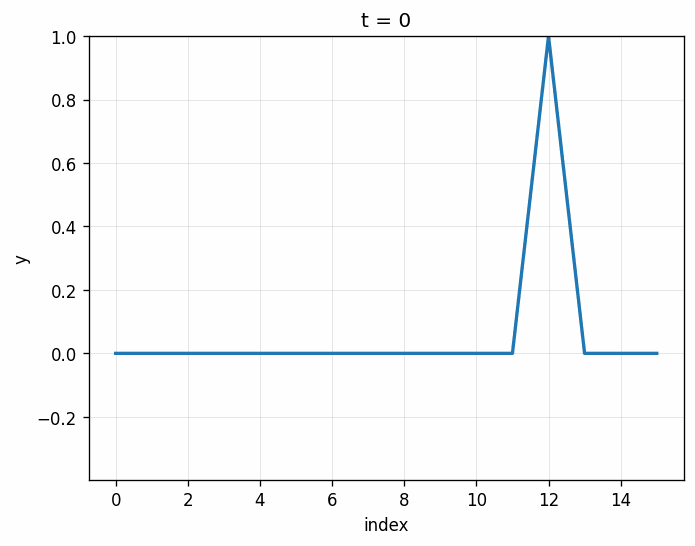

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from io import BytesIO

def arrays_to_line_gif(
    ys,
    gif_path="output.gif",
    x=None,
    fps=10,
    duration=None,          # seconds per frame; overrides fps if set
    ylim="global",          # "global", "per_frame", or tuple (ymin, ymax)
    xlim="auto",            # "auto" or tuple (xmin, xmax)
    title_fn=None,          # function(t)->str
    xlabel=None,
    ylabel=None,
    linewidth=2,
    dpi=120,
):
    """
    ys: list of 1D arrays (y-values per frame)
    x:  None (use indices) OR 1D array shared by all frames OR list of 1D arrays per frame
    """

    if len(ys) == 0:
        raise ValueError("ys is empty")

    # Normalize input arrays
    ys = [np.asarray(y).ravel() for y in ys]

    # Build x for each frame
    if x is None:
        xs = [np.arange(len(y)) for y in ys]
    else:
        if isinstance(x, (list, tuple)):
            if len(x) != len(ys):
                raise ValueError("If x is a list, it must have same length as ys")
            xs = [np.asarray(xi).ravel() for xi in x]
        else:
            x_arr = np.asarray(x).ravel()
            xs = [x_arr for _ in ys]

    # y-limits
    if ylim == "global":
        y_all = np.concatenate([y[np.isfinite(y)] for y in ys if y.size])
        if y_all.size == 0:
            ymin, ymax = -1.0, 1.0
        else:
            ymin, ymax = float(np.min(y_all)), float(np.max(y_all))
            if ymin == ymax:
                ymin -= 1.0
                ymax += 1.0
        global_ylim = (ymin, ymax)
    elif isinstance(ylim, tuple) and len(ylim) == 2:
        global_ylim = (float(ylim[0]), float(ylim[1]))
    elif ylim == "per_frame":
        global_ylim = None
    else:
        raise ValueError('ylim must be "global", "per_frame", or (ymin, ymax)')

    frames = []

    for t, (xi, yi) in enumerate(zip(xs, ys)):
        fig, ax = plt.subplots()
        ax.plot(xi, yi, linewidth=linewidth)

        # Limits
        if global_ylim is not None:
            ax.set_ylim(*global_ylim)
        else:
            yfinite = yi[np.isfinite(yi)]
            if yfinite.size:
                ymin, ymax = float(yfinite.min()), float(yfinite.max())
                if ymin == ymax:
                    ymin -= 1.0
                    ymax += 1.0
                ax.set_ylim(ymin, ymax)

        if xlim != "auto":
            ax.set_xlim(*xlim)

        # Labels / title
        if xlabel: ax.set_xlabel(xlabel)
        if ylabel: ax.set_ylabel(ylabel)
        if title_fn is not None:
            ax.set_title(title_fn(t))
        else:
            ax.set_title(f"Frame {t}")

        ax.grid(True, alpha=0.3)

        # Render to PNG buffer
        buf = BytesIO()
        fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
        plt.close(fig)
        buf.seek(0)
        frames.append(imageio.imread(buf))

    # Save GIF
    if duration is not None:
        imageio.mimsave(gif_path, frames, duration=float(duration))
    else:
        imageio.mimsave(gif_path, frames, fps=int(fps))

    return gif_path

ys = frames

gif = arrays_to_line_gif(
    ys,
    gif_path="sine.gif",
    fps=12,
    ylim="global",
    xlabel="index",
    ylabel="y",
    title_fn=lambda t: f"t = {t}"
)

display(Image(filename="sine.gif"))

In [45]:
direct_mps.to_dense()

array([[-9.64672007e-18+1.22971552e-19j],
       [-2.18885445e-16+7.07179454e-17j],
       [ 1.26627835e-17+9.93346654e-02j],
       [ 9.90033289e-01-1.25773655e-16j],
       [-1.45535632e-19-4.17210196e-19j],
       [-9.96671108e-03-2.16614883e-17j],
       [ 4.18782959e-18-4.33081230e-19j],
       [ 2.77615485e-17+9.93346654e-02j]])